In [ ]:
import pandas as pd

In [ ]:
seg = pd.read_csv("segmen.csv")

In [ ]:
opencellid = pd.read_csv("/content/opencellid_morocco.csv")

In [ ]:
trafic = pd.read_csv("/content/casablanca_traffic_insights_scores.csv")

In [ ]:
scr = trafic[["geometry", "traffic_score"]]

In [ ]:
kazyon = pd.read_csv("/content/maroc_Kazyon_market.csv")

In [ ]:
kazyon.iloc[0]

,0
name,Kazyon Market
latitude,35.771169
longitude,-5.810829
address,NaN
phone,NaN
status,NaN
category,4.3(15)
image_url,https://lh3.googleusercontent.com/gps-cs-s/AC9...


In [ ]:
isochrone = pd.read_csv("/content/isochrones_10.csv")

In [ ]:
isochrone.drop(columns=["ID"], inplace=True)

In [ ]:
isochrone.head()

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP
0,-7.660345,33.570794,10,driving-car,672132
1,-7.639810,33.592176,10,driving-car,662641
2,-7.629357,33.586978,10,driving-car,843732
3,-7.634833,33.556384,10,driving-car,1062919
4,-7.641768,33.593092,10,driving-car,531838


In [ ]:
data = {
    "CENTER_LON": [-7.660345, -7.639810, -7.629357, -7.634833, -7.641768],
    "CENTER_LAT": [33.570794, 33.592176, 33.586978, 33.556384, 33.593092],
    "AA_MINS": [10, 10, 10, 10, 10],
    "AA_MODE": ["driving-car"]*5,
    "TOTAL_POP": [48732, 52641, 43732, 36919, 51838]
}

isochrones_df = pd.DataFrame(data)

isochrones_df

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP
0,-7.660345,33.570794,10,driving-car,48732
1,-7.639810,33.592176,10,driving-car,52641
2,-7.629357,33.586978,10,driving-car,43732
3,-7.634833,33.556384,10,driving-car,36919
4,-7.641768,33.593092,10,driving-car,51838


In [ ]:
isochrones_df.columns, scr.columns

(Index(['CENTER_LON', 'CENTER_LAT', 'AA_MINS', 'AA_MODE', 'TOTAL_POP'], dtype='object'),
 Index(['geometry', 'traffic_score'], dtype='object'))

In [ ]:
isochrone.iloc[0]

,0
ID,NaN
CENTER_LON,-7.660345
CENTER_LAT,33.570794
AA_MINS,10
AA_MODE,foot-walking
TOTAL_POP,17286


In [ ]:
import geopandas as gpd
import pandas as pd


joined = gpd.sjoin(roads, isochrones, how="inner", predicate="intersects")

# moyenne du score de trafic par isochrone
traffic_scores = joined.groupby("isochrone_id")["trafic_score"].mean().reset_index()
traffic_scores.rename(columns={"trafic_score": "mean_trafic_score"}, inplace=True)

# résultat: DataFrame avec un score de trafic moyen par isochrone
print(traffic_scores)

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt

isochrones_gdf = gpd.GeoDataFrame(
    isochrone,
    geometry=[Point(xy) for xy in zip(isochrone.CENTER_LON, isochrone.CENTER_LAT)],
    crs="EPSG:4326"
)

# Ensure traffic_gdf CRS matches

# trafic['geometry'] = trafic['geometry'].apply(wkt.loads)
traffic_gdf = gpd.GeoDataFrame(trafic, geometry='geometry', crs="EPSG:4326")

isochrones_gdf['geometry'] = isochrones_gdf.geometry.buffer(0.01)

# joined = gpd.sjoin(traffic_gdf, isochrones_gdf, how="inner", predicate="intersects")

# Remove any existing 'index_right' column if present
if 'index_right' in isochrones_gdf.columns:
    isochrones_gdf = isochrones_gdf.drop(columns=['index_right'])
if 'index_right' in traffic_gdf.columns:
    traffic_gdf = traffic_gdf.drop(columns=['index_right'])


isochrones_gdf['isochrone_id'] = range(len(isochrones_gdf))
# Spatial join
joined = gpd.sjoin(
    traffic_gdf,
    isochrones_gdf,
    how="inner",
    predicate="intersects",
    lsuffix='left',
    rsuffix='right'  # avoids conflicts
)


mean_traffic = joined.groupby('isochrone_id')['traffic_score'].mean().reset_index()

iso_with_traffic = isochrones_gdf.merge(mean_traffic, on='isochrone_id', how='left')
huff_input = iso_with_traffic[['CENTER_LON', 'CENTER_LAT', 'TOTAL_POP', 'traffic_score']]



/tmp/ipython-input-210346759.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  isochrones_gdf['geometry'] = isochrones_gdf.geometry.buffer(0.01)


In [ ]:
huff_input.head(15)

,CENTER_LON,CENTER_LAT,TOTAL_POP,traffic_score
0,-7.660345,33.570794,672132,61.784038
1,-7.639810,33.592176,662641,62.354560
2,-7.629357,33.586978,843732,62.438865
3,-7.634833,33.556384,1062919,62.477390
4,-7.641768,33.593092,531838,62.519831
5,-7.636310,33.589402,634669,63.235717
6,-7.636386,33.587507,671277,63.992916
7,-7.641698,33.588046,568855,63.690561
8,-7.654606,33.595696,568559,64.287679
9,-7.663903,33.562661,705077,58.070657


In [ ]:
isochrones_gdf.head()

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP,geometry
0,-7.660345,33.570794,10,driving-car,672132,"POLYGON ((-7.65035 33.57079, -7.65039 33.56981..."
1,-7.639810,33.592176,10,driving-car,662641,"POLYGON ((-7.62981 33.59218, -7.62986 33.5912,..."
2,-7.629357,33.586978,10,driving-car,843732,"POLYGON ((-7.61936 33.58698, -7.6194 33.586, -..."
3,-7.634833,33.556384,10,driving-car,1062919,"POLYGON ((-7.62483 33.55638, -7.62488 33.5554,..."
4,-7.641768,33.593092,10,driving-car,531838,"POLYGON ((-7.63177 33.59309, -7.63182 33.59211..."


In [ ]:
isochrones_gdf = isochrones_gdf.reset_index().rename(columns={'index':'isochrone_id'})
isochrones_gdf.set_index('isochrone_id', inplace=True)

isochrones_gdf.head()

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP,geometry
isochrone_id,,,,,,
0,-7.660345,33.570794,10,driving-car,672132,POINT (-7.66035 33.57079)
1,-7.639810,33.592176,10,driving-car,662641,POINT (-7.63981 33.59218)
2,-7.629357,33.586978,10,driving-car,843732,POINT (-7.62936 33.58698)
3,-7.634833,33.556384,10,driving-car,1062919,POINT (-7.63483 33.55638)
4,-7.641768,33.593092,10,driving-car,531838,POINT (-7.64177 33.59309)


In [ ]:
traffic_gdf = traffic_gdf.reset_index().rename(columns={'index':'index'})
traffic_gdf.set_index('index', inplace=True)

traffic_gdf.head()

,traffic_id,streetName,distance,shape,timeSet,dateRange,harmonicAverageSpeed,medianSpeed,averageSpeed,standardDeviationSpeed,...,travelTimeRatio,geometry,index_right,highway,oneway,length,lanes,width_estimated,dist,traffic_score
index,,,,,,,,,,,,,,,,,,,,,
0,98671,NaN,76.00,"LINESTRING(-7.48715 33.59011, -7.48757 33.5907)",2,1,24.5,30.0,30.2,10.4,...,1.0,"LINESTRING (-7.48715 33.59011, -7.48757 33.5907)",117436,residential,False,37.176047,2.0,6.5,0.0,79.885144
1,98685,NaN,15.41,"LINESTRING(-7.703 33.55172, -7.70289 33.55162)",2,1,17.3,24.0,23.4,7.8,...,1.0,"LINESTRING (-7.703 33.55172, -7.70289 33.55162)",46758,residential,False,44.600017,2.0,6.5,0.0,55.477165
2,98674,كم 16,21.32,"LINESTRING(-7.45728 33.63314, -7.45713 33.633)",2,1,7.1,6.5,7.1,0.8,...,1.0,"LINESTRING (-7.45728 33.63314, -7.45713 33.633)",138857,residential,False,24.062420,2.0,6.5,0.0,41.764445
3,98677,R310,263.19,"LINESTRING(-7.70129 33.47425, -7.70128 33.4742...",2,1,50.7,53.0,53.7,12.6,...,1.0,"LINESTRING (-7.70129 33.47425, -7.70128 33.474...",45040,secondary,False,751.613329,2.0,6.5,0.0,73.971248
4,98701,NaN,111.51,"LINESTRING(-7.62127 33.52032, -7.62144 33.5203...",2,1,23.2,21.0,30.3,20.9,...,1.0,"LINESTRING (-7.62127 33.52032, -7.62144 33.520...",84054,residential,False,172.670716,2.0,6.5,0.0,47.829460


In [ ]:
marjane_df = pd.read_csv("/content/maroc_marjane_market.csv")
bin_df = pd.read_csv("/content/maroc_bim_stores.csv")

In [ ]:
from shapely.geometry import Point
iso_gdf = gpd.GeoDataFrame(
    isochrone,
    geometry=[Point(xy) for xy in zip(isochrone.CENTER_LON, isochrone.CENTER_LAT)],
    crs="EPSG:4326"
)

# Ensure traffic_gdf CRS matches
traffic_gdf = traffic_gdf.to_crs(iso_gdf.crs)

In [ ]:
kazyon.columns

Index(['name', 'latitude', 'longitude', 'address', 'phone', 'status',
       'category', 'image_url'],
      dtype='object')

In [ ]:
conc_df = pd.concat([kazyon, marjane_df, bin_df], ignore_index=True)

In [ ]:
conc_df.drop(columns=["address", "phone", "category", "image_url"], inplace=True)

In [ ]:
conc_df.drop(columns=["status"], inplace=True)

In [ ]:
conc_df.head()

,name,latitude,longitude
0,Kazyon Market,35.771169,-5.810829
1,Kazyon market,35.735865,-5.853440
2,Kazyon Market,35.750900,-5.802360
3,Kazyon Market,35.786749,-5.820588
4,Kazyon Market,35.709615,-5.910943


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# Concurrents en GeoDataFrame
concurrence_gdf = gpd.GeoDataFrame(
    conc_df,
    geometry=[Point(xy) for xy in zip(conc_df.longitude, conc_df.latitude)],
    crs="EPSG:4326"
)



# Jointure spatiale pour compter les concurrents dans chaque isochrone
joined_comp = gpd.sjoin(concurrence_gdf, isochrones_gdf, how='inner', predicate='intersects')

# Agrégation du nombre de concurrents par isochrone
competitor_count = joined_comp.groupby('isochrone_id')['name'].count().reset_index()
competitor_count.rename(columns={'name': 'num_competitors'}, inplace=True)

# Fusion avec le GeoDataFrame des isochrones
iso_with_competition = isochrones_gdf.merge(competitor_count, on='isochrone_id', how='left')
iso_with_competition['num_competitors'] = iso_with_competition['num_competitors'].fillna(0)

In [ ]:
iso_with_competition.head()

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP,geometry,isochrone_id,num_competitors
0,-7.660345,33.570794,10,driving-car,672132,"POLYGON ((-7.65035 33.57079, -7.65039 33.56981...",0,5.0
1,-7.639810,33.592176,10,driving-car,662641,"POLYGON ((-7.62981 33.59218, -7.62986 33.5912,...",1,19.0
2,-7.629357,33.586978,10,driving-car,843732,"POLYGON ((-7.61936 33.58698, -7.6194 33.586, -...",2,17.0
3,-7.634833,33.556384,10,driving-car,1062919,"POLYGON ((-7.62483 33.55638, -7.62488 33.5554,...",3,7.0
4,-7.641768,33.593092,10,driving-car,531838,"POLYGON ((-7.63177 33.59309, -7.63182 33.59211...",4,19.0


In [ ]:
huff_input['isochrone_id'] = range(len(huff_input))

/tmp/ipython-input-921785527.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  huff_input['isochrone_id'] = range(len(huff_input))


In [ ]:
new_huff_input = huff_input.merge(iso_with_competition[['isochrone_id', 'num_competitors']], on='isochrone_id', how='left')

In [ ]:
new_huff_input.columns

Index(['CENTER_LON', 'CENTER_LAT', 'TOTAL_POP', 'traffic_score',
       'isochrone_id', 'num_competitors'],
      dtype='object')

In [ ]:
new_huff_input[['CENTER_LON', 'CENTER_LAT', 'TOTAL_POP', 'traffic_score', 'num_competitors']].head()

,CENTER_LON,CENTER_LAT,TOTAL_POP,traffic_score,num_competitors
0,-7.660345,33.570794,672132,61.784038,5.0
1,-7.639810,33.592176,662641,62.354560,19.0
2,-7.629357,33.586978,843732,62.438865,17.0
3,-7.634833,33.556384,1062919,62.477390,7.0
4,-7.641768,33.593092,531838,62.519831,19.0


In [ ]:
opencellid["radio_type"].unique()

array(['GSM', 'UMTS', 'LTE'], dtype=object)

In [ ]:
cell_df_filtered = opencellid[opencellid['radio_type'].apply(lambda x: any(r in ['UMTS','LTE'] for r in (x if isinstance(x,list) else [x])))]


In [ ]:
cell_df_filtered['radio_type'] = cell_df_filtered['radio_type'].apply(lambda x: [r for r in x if r in ['UMTS','LTE']])
cell_exploded = cell_df_filtered.explode('radio_type')

/tmp/ipython-input-2058323367.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cell_df_filtered['radio_type'] = cell_df_filtered['radio_type'].apply(lambda x: [r for r in x if r in ['UMTS','LTE']])


In [ ]:
cell_exploded

,radio_type,mcc,mnc,lac,cellid,unit,lon,lat,range_meter,samples,changeable,created,updated,averageSignal
160,NaN,604,1,418,27395423,504,-6.8264,34.0253,1207,21,1,2014-04-19 13:09:57+00:00,2024-08-02 19:59:02+00:00,0
241,NaN,604,1,418,27397074,482,-6.8348,34.0280,1000,35,1,2015-01-07 11:24:53+00:00,2024-08-02 19:59:02+00:00,0
242,NaN,604,1,418,27395246,267,-6.8448,34.0221,2128,17,1,2015-01-07 11:29:57+00:00,2024-08-02 19:59:02+00:00,0
1057,NaN,604,1,4182,25634563,0,-6.8381,34.0224,1000,9,1,2016-03-24 19:51:41+00:00,2024-08-03 19:15:02+00:00,0
1058,NaN,604,1,4182,25638404,0,-6.8302,34.0323,1461,38,1,2016-03-24 19:51:41+00:00,2024-08-03 19:15:02+00:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10948,NaN,604,0,31740,28465952,0,-7.5182,33.6215,1000,1,1,2025-06-14 01:41:24+00:00,2025-06-14 01:41:24+00:00,0
10949,NaN,604,0,31740,28620321,0,-7.5054,33.6212,1000,1,1,2025-06-15 07:50:37+00:00,2025-06-15 07:50:37+00:00,0
10950,NaN,604,1,407,26734407,0,-7.6715,33.5925,1000,1,1,2025-06-15 14:16:10+00:00,2025-06-15 14:16:10+00:00,0
10951,NaN,604,2,1352,20813817,0,-5.4899,35.8867,1000,1,1,2025-06-23 03:13:27+00:00,2025-06-23 03:13:27+00:00,0


In [ ]:
cell_gdf = gpd.GeoDataFrame(
    cell_exploded,
    geometry=[Point(xy) for xy in zip(cell_exploded.lon, cell_exploded.lat)],
    crs="EPSG:4326"
)

In [ ]:
cell_gdf['geometry'] = cell_gdf.buffer(cell_gdf['range_meter'] / 111000)  # approximate degrees


/tmp/ipython-input-716641868.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cell_gdf['geometry'] = cell_gdf.buffer(cell_gdf['range_meter'] / 111000)  # approximate degrees


In [ ]:
joined = gpd.sjoin(cell_gdf, isochrones_gdf, how='inner', predicate='intersects')

In [ ]:
antenna_count = joined.groupby('isochrone_id')['cellid'].count().reset_index().rename(columns={'cellid':'num_antenna_3g4g'})


In [ ]:
iso_with_cell = isochrones_gdf.merge(antenna_count, on='isochrone_id', how='left')

In [ ]:
mean_antennas = iso_with_cell['num_antenna_3g4g'].mean()

In [ ]:
iso_with_cell['num_antenna_3g4g'] = iso_with_cell['num_antenna_3g4g'].fillna(mean_antennas)

In [ ]:
new_h_in = new_huff_input.merge(iso_with_cell[['isochrone_id', 'num_antenna_3g4g']], on='isochrone_id', how='left')

In [ ]:
new_h_in.head()

,CENTER_LON,CENTER_LAT,TOTAL_POP,traffic_score,isochrone_id,num_competitors,num_antenna_3g4g
0,-7.660345,33.570794,672132,61.784038,0,5.0,8.0
1,-7.639810,33.592176,662641,62.354560,1,19.0,43.0
2,-7.629357,33.586978,843732,62.438865,2,17.0,57.0
3,-7.634833,33.556384,1062919,62.477390,3,7.0,12.0
4,-7.641768,33.593092,531838,62.519831,4,19.0,42.0


In [ ]:
new_h_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CENTER_LON        165 non-null    float64
 1   CENTER_LAT        165 non-null    float64
 2   TOTAL_POP         165 non-null    int64  
 3   traffic_score     52 non-null     float64
 4   isochrone_id      165 non-null    int64  
 5   num_competitors   165 non-null    float64
 6   num_antenna_3g4g  165 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 9.2 KB


In [ ]:
segmen_1 , segmen_2, segmen_3 = pd.read_csv("/content/segmen_20250825_152556.csv") , pd.read_csv("/content/segmen_20250825_155528.csv") , pd.read_csv("/content/segmen_20250825_160813.csv")

In [ ]:
segmentation = pd.concat([segmen_1, segmen_2, segmen_3], ignore_index=True)

In [ ]:
segmentation['geometry'] = segmentation['geometry'].apply(wkt.loads)

In [ ]:
seg_gdf = gpd.GeoDataFrame(segmentation, geometry='geometry', crs='EPSG:4326')

In [ ]:
seg_gdf = seg_gdf.to_crs("EPSG:32629")

In [ ]:
seg_gdf['area_m2'] = seg_gdf.geometry.area

In [ ]:
seg_gdf.head()

,geometry,class_id,class_name,area_m2
0,"POLYGON ((628054.524 3718834.766, 628054.529 3...",7,traditionnel,0.663983
1,"POLYGON ((627971.857 3718832.336, 627971.861 3...",7,traditionnel,0.553319
2,"POLYGON ((628010.865 3718832.856, 628010.87 37...",2,zone-verte,0.110664
3,"POLYGON ((627915.506 3718831.917, 627915.51 37...",2,zone-verte,0.553319
4,"POLYGON ((628051.199 3718834.057, 628051.212 3...",7,traditionnel,1.106639


In [ ]:
isochrones_gdf = isochrones_gdf.to_crs(seg_gdf.crs)

In [ ]:
joined = gpd.sjoin(seg_gdf, isochrones_gdf, how='inner', predicate='intersects')

In [ ]:
area_per_class = joined.groupby(['isochrone_id', 'class_name'])['area_m2'].sum().unstack(fill_value=0).reset_index()

In [ ]:
hi = isochrones_gdf.merge(area_per_class, on='isochrone_id', how='left')

In [ ]:
hi.fillna(0, inplace=True)

In [ ]:
hi.drop(columns=["eau", "route", "zone-verte", "geometry"], inplace=True)

In [ ]:
hi.head()

,CENTER_LON,CENTER_LAT,AA_MINS,AA_MODE,TOTAL_POP,isochrone_id,Villa,appartement,non-residentiel,traditionnel
0,-7.660345,33.570794,10,driving-car,672132,0,318802.103794,20007.344343,29502.749125,4073.152345
1,-7.639810,33.592176,10,driving-car,662641,1,92521.731816,845227.086047,134177.879740,105196.092346
2,-7.629357,33.586978,10,driving-car,843732,2,32376.800695,517449.198169,99426.715008,142590.098662
3,-7.634833,33.556384,10,driving-car,1062919,3,0.000000,0.000000,0.000000,0.000000
4,-7.641768,33.593092,10,driving-car,531838,4,131173.574984,697675.870142,112565.911955,71594.068414


In [ ]:
hi.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CENTER_LON       165 non-null    float64
 1   CENTER_LAT       165 non-null    float64
 2   AA_MINS          165 non-null    int64  
 3   AA_MODE          165 non-null    object 
 4   TOTAL_POP        165 non-null    int64  
 5   isochrone_id     165 non-null    int64  
 6   Villa            165 non-null    float64
 7   appartement      165 non-null    float64
 8   non-residentiel  165 non-null    float64
 9   traditionnel     165 non-null    float64
dtypes: float64(6), int64(3), object(1)
memory usage: 13.0+ KB


In [ ]:
final_huff_input = new_h_in.merge(hi, on='isochrone_id', how='left')

In [ ]:
final_huff_input.head()

,CENTER_LON_x,CENTER_LAT_x,TOTAL_POP_x,traffic_score,isochrone_id,num_competitors,num_antenna_3g4g,CENTER_LON_y,CENTER_LAT_y,AA_MINS,AA_MODE,TOTAL_POP_y,Villa,appartement,non-residentiel,traditionnel
0,-7.660345,33.570794,672132,61.784038,0,5.0,8.0,-7.660345,33.570794,10,driving-car,672132,318802.103794,20007.344343,29502.749125,4073.152345
1,-7.639810,33.592176,662641,62.354560,1,19.0,43.0,-7.639810,33.592176,10,driving-car,662641,92521.731816,845227.086047,134177.879740,105196.092346
2,-7.629357,33.586978,843732,62.438865,2,17.0,57.0,-7.629357,33.586978,10,driving-car,843732,32376.800695,517449.198169,99426.715008,142590.098662
3,-7.634833,33.556384,1062919,62.477390,3,7.0,12.0,-7.634833,33.556384,10,driving-car,1062919,0.000000,0.000000,0.000000,0.000000
4,-7.641768,33.593092,531838,62.519831,4,19.0,42.0,-7.641768,33.593092,10,driving-car,531838,131173.574984,697675.870142,112565.911955,71594.068414


In [ ]:
final_huff_input.drop(columns=["isochrone_id", "CENTER_LON_y", "CENTER_LAT_y","AA_MINS","AA_MODE","TOTAL_POP_y"], inplace=True)

,CENTER_LON_x,CENTER_LAT_x,TOTAL_POP_x,traffic_score,num_competitors,num_antenna_3g4g,Villa,appartement,non-residentiel,traditionnel
0,-7.660345,33.570794,672132,61.784038,5.0,8.0,318802.103794,20007.344343,29502.749125,4073.152345
1,-7.639810,33.592176,662641,62.354560,19.0,43.0,92521.731816,845227.086047,134177.879740,105196.092346
2,-7.629357,33.586978,843732,62.438865,17.0,57.0,32376.800695,517449.198169,99426.715008,142590.098662
3,-7.634833,33.556384,1062919,62.477390,7.0,12.0,0.000000,0.000000,0.000000,0.000000
4,-7.641768,33.593092,531838,62.519831,19.0,42.0,131173.574984,697675.870142,112565.911955,71594.068414
5,-7.636310,33.589402,634669,63.235717,17.0,43.0,22150.152868,846967.927396,148836.515919,134428.515372
6,-7.636386,33.587507,671277,63.992916,21.0,46.0,31569.499428,847084.332519,162745.972172,132370.367912
7,-7.641698,33.588046,568855,63.690561,14.0,43.0,137685.830607,799610.141244,158090.602816,131270.883463
8,-7.654606,33.595696,568559,64.287679,5.0,23.0,492094.404235,79352.462679,40347.514268,13741.289569
9,-7.663903,33.562661,705077,58.070657,8.0,4.0,11889.038764,111630.242762,7497.486469,58695.228327


In [ ]:
building_cols = ["Villa", "appartement", "non-residentiel", "traditionnel"]

# Keep only rows where at least one building type > 0
df_filtered = final_huff_input[(final_huff_input[building_cols] != 0).any(axis=1)]

In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 156
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CENTER_LON_x      40 non-null     float64
 1   CENTER_LAT_x      40 non-null     float64
 2   TOTAL_POP_x       40 non-null     int64  
 3   traffic_score     40 non-null     float64
 4   num_competitors   40 non-null     float64
 5   num_antenna_3g4g  40 non-null     float64
 6   Villa             40 non-null     float64
 7   appartement       40 non-null     float64
 8   non-residentiel   40 non-null     float64
 9   traditionnel      40 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.4 KB


In [ ]:
df_filtered.to_csv("input_huff_model.csv", index=False)

In [ ]:
df_filtered.head()

,CENTER_LON_x,CENTER_LAT_x,TOTAL_POP_x,traffic_score,num_competitors,num_antenna_3g4g,Villa,appartement,non-residentiel,traditionnel
0,-7.660345,33.570794,672132,61.784038,5.0,8.0,318802.103794,20007.344343,29502.749125,4073.152345
1,-7.639810,33.592176,662641,62.354560,19.0,43.0,92521.731816,845227.086047,134177.879740,105196.092346
2,-7.629357,33.586978,843732,62.438865,17.0,57.0,32376.800695,517449.198169,99426.715008,142590.098662
4,-7.641768,33.593092,531838,62.519831,19.0,42.0,131173.574984,697675.870142,112565.911955,71594.068414
5,-7.636310,33.589402,634669,63.235717,17.0,43.0,22150.152868,846967.927396,148836.515919,134428.515372


In [ ]:
df_filtered.columns

Index(['CENTER_LON_x', 'CENTER_LAT_x', 'TOTAL_POP_x', 'traffic_score',
       'num_competitors', 'num_antenna_3g4g', 'Villa', 'appartement',
       'non-residentiel', 'traditionnel'],
      dtype='object')

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

In [3]:
df_filtered = pd.read_csv("input_huff_model.csv")
df_filtered.head()

,CENTER_LON_x,CENTER_LAT_x,TOTAL_POP_x,traffic_score,num_competitors,num_antenna_3g4g,Villa,appartement,non-residentiel,traditionnel
0,-7.660345,33.570794,672132,61.784038,5.0,8.0,318802.103794,20007.344343,29502.749125,4073.152345
1,-7.639810,33.592176,662641,62.354560,19.0,43.0,92521.731816,845227.086047,134177.879740,105196.092346
2,-7.629357,33.586978,843732,62.438865,17.0,57.0,32376.800695,517449.198169,99426.715008,142590.098662
3,-7.641768,33.593092,531838,62.519831,19.0,42.0,131173.574984,697675.870142,112565.911955,71594.068414
4,-7.636310,33.589402,634669,63.235717,17.0,43.0,22150.152868,846967.927396,148836.515919,134428.515372


In [ ]:
import pandas as pd
import numpy as np
import numpy as np

def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df_filtered["distance_km"] = haversine(
    df_filtered["CENTER_LON_x"], df_filtered["CENTER_LAT_x"],
    df_filtered["CENTER_LON_x"].mean(), df_filtered["CENTER_LAT_x"].mean()
)


WEIGHTS = {
    "TOTAL_POP_x": 0.3,
    "traffic_score": 0.25,
    "num_competitors": -0.2,
    "num_antenna_3g4g": 0.15,
    "Villa": 0.06,
    "appartement": 0.06,
    "non-residentiel": 0.02,
    "traditionnel": 0.06
}

ALPHA = 1.2
BETA = 2.0

def compute_attractiveness(df, weights):
    score = np.zeros(len(df))
    for col, w in weights.items():
        if col in df.columns:
            score += w * df[col].fillna(0).values
    score = np.maximum(score, 1e-6)
    return score

def compute_huff_probabilities(df, weights, alpha, beta, demand_col="TOTAL_POP_x", dist_col="distance_km"):

    df["attractiveness"] = compute_attractiveness(df, weights)
    numerator = (df["attractiveness"] ** alpha) / (df[dist_col] ** beta)
    df["huff_prob"] = numerator / numerator.sum()
    df["expected_demand"] = df[demand_col].sum() * df["huff_prob"]

    return df[[
        "CENTER_LON_x","CENTER_LAT_x","attractiveness",
        "huff_prob","expected_demand"
    ]]

huff_results = compute_huff_probabilities(df_filtered, WEIGHTS, ALPHA, BETA)
huff_results.head(10)


/tmp/ipython-input-3798886978.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["distance_km"] = haversine(
/tmp/ipython-input-3798886978.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["attractiveness"] = compute_attractiveness(df, weights)
/tmp/ipython-input-3798886978.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

,CENTER_LON_x,CENTER_LAT_x,attractiveness,huff_prob,expected_demand
0,-7.660345,33.570794,222818.257021,0.001062,3.438445e+04
1,-7.639810,33.592176,264070.790847,0.019649,6.359249e+05
2,-7.629357,33.586978,296673.859868,0.133346,4.315680e+06
4,-7.641768,33.593092,215847.459009,0.009823,3.179194e+05
5,-7.636310,33.589402,253609.084986,0.089930,2.910536e+06
6,-7.636386,33.587507,265318.169664,0.123518,3.997593e+06
7,-7.641698,33.588046,237951.896015,0.017171,5.557191e+05
8,-7.654606,33.595696,206504.461594,0.002001,6.475623e+04
9,-7.663903,33.562661,222619.437985,0.000663,2.146636e+04
10,-7.679629,33.586510,132121.489597,0.000302,9.782340e+03


In [ ]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic

# Example: huff_input contains candidate stores
# Columns: CENTER_LAT_x, CENTER_LON_x, attractiveness, TOTAL_POP_x (population at each isochrone)

# Step 0: define alpha and beta
alpha = 1.0  # sensitivity to attractiveness
beta = 2.0   # sensitivity to distance

# Step 1: define population points
# For demo, let's assume each isochrone is a population point
population_points = huff_input[['CENTER_LAT_x', 'CENTER_LON_x', 'TOTAL_POP_x']].copy()
population_points['id'] = population_points.index

# Step 2: compute distance matrix (population point i to store j)
distances = np.zeros((len(population_points), len(huff_input)))
for i, pop_row in population_points.iterrows():
    for j, store_row in huff_input.iterrows():
        coord_i = (pop_row['CENTER_LAT_x'], pop_row['CENTER_LON_x'])
        coord_j = (store_row['CENTER_LAT_x'], store_row['CENTER_LON_x'])
        distances[i, j] = geodesic(coord_i, coord_j).km  # distance in km

# Step 3: compute numerator of Huff model
A = huff_input['attractiveness'].values
numerator = A**alpha / np.power(distances, beta)

# Avoid division by zero if distance is zero
numerator[np.isinf(numerator)] = A[np.isinf(numerator)]**alpha

# Step 4: compute denominator for each population point
denominator = numerator.sum(axis=1, keepdims=True)

# Step 5: compute P_ij matrix
P_ij = numerator / denominator

# Step 6: compute expected demand from each population point
pop_sizes = population_points['TOTAL_POP_x'].values.reshape(-1, 1)
expected_demand_matrix = P_ij * pop_sizes

# Step 7: sum expected demand per store (columns)
total_expected_demand_per_store = expected_demand_matrix.sum(axis=0)

# Step 8: create results dataframe
huff_results_full = huff_input.copy()
huff_results_full['expected_demand'] = total_expected_demand_per_store
huff_results_full['huff_prob'] = total_expected_demand_per_store / total_expected_demand_per_store.sum()

# huff_results_full now contains P_ij implicitly in expected demand computation


In [9]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic

# ==============================
# CONFIGURATION
# ==============================
ALPHA = 1.2   # sensitivity to attractiveness
BETA = 2.0    # distance friction
EPSILON = 1e-6  # to avoid division by zero

# ==============================
# STEP 1. ATTRACTIVENESS FUNCTION
# ==============================
def compute_attractiveness(df, weights):
    """
    Compute weighted attractiveness score for each candidate store.
    """
    score = np.zeros(len(df))
    for col, w in weights.items():
        if col in df.columns:
            score += w * df[col].fillna(0).values
    return np.maximum(score, EPSILON)


# Example weights (domain expert can adjust)
WEIGHTS = {
    "traffic_score": 0.25,
    "num_competitors": -0.2,
    "num_antenna_3g4g": 0.07,
    "Villa": 0.08,
    "appartement": 0.1,
    "non-residentiel": 0.02,
    "traditionnel": 0.08
}


# ==============================
# STEP 2. DISTANCE MATRIX
# ==============================
def compute_distance_matrix(demand_df, store_df):
    """
    Compute distance matrix between demand points and candidate stores.
    Returns array shape (n_demand, n_stores).
    """
    distances = np.zeros((len(demand_df), len(store_df)))
    for i, row_i in demand_df.iterrows():
        coord_i = (row_i['CENTER_LAT_x'], row_i['CENTER_LON_x'])
        for j, row_j in store_df.iterrows():
            coord_j = (row_j['CENTER_LAT_x'], row_j['CENTER_LON_x'])
            distances[i, j] = geodesic(coord_i, coord_j).km + EPSILON
    return distances


# ==============================
# STEP 3. HUFF MODEL
# ==============================
def huff_model(demand_df, store_df, weights, alpha=ALPHA, beta=BETA):
    """
    Apply Huff model on split dataframes:
    - demand_df: contains demand points with TOTAL_POP_x
    - store_df: contains candidate store sites with attractiveness features
    """
    store_df = store_df.copy()
    demand_df = demand_df.copy()

    # Compute attractiveness for stores
    store_df['attractiveness'] = compute_attractiveness(store_df, weights)

    # Compute distance matrix (n_demand x n_stores)
    distances = compute_distance_matrix(demand_df, store_df)

    # Numerator: store attractiveness weighted by distance
    numerator = (store_df['attractiveness'].values[np.newaxis, :] ** alpha) / (distances ** beta)

    # Denominator: sum across all candidate stores for each demand point
    denominator = numerator.sum(axis=1, keepdims=True)

    # Choice probabilities P_ij (n_demand x n_stores)
    P_ij = numerator / denominator

    # Expected demand allocation
    pop_sizes = demand_df['TOTAL_POP_x'].values.reshape(-1, 1)
    expected_demand_matrix = P_ij * pop_sizes  # demand → store allocation

    # Aggregate expected demand per store
    store_df['expected_demand'] = expected_demand_matrix.sum(axis=0)
    store_df['huff_prob'] = store_df['expected_demand'] / store_df['expected_demand'].sum()

    return store_df, P_ij, expected_demand_matrix



In [14]:
total_weights = sum(WEIGHTS.values())
total_weights

0.4

In [10]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CENTER_LON_x      40 non-null     float64
 1   CENTER_LAT_x      40 non-null     float64
 2   TOTAL_POP_x       40 non-null     int64  
 3   traffic_score     40 non-null     float64
 4   num_competitors   40 non-null     float64
 5   num_antenna_3g4g  40 non-null     float64
 6   Villa             40 non-null     float64
 7   appartement       40 non-null     float64
 8   non-residentiel   40 non-null     float64
 9   traditionnel      40 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.3 KB


In [11]:
df = df_filtered.copy()

In [12]:
demand_df = df.sample(10, random_state=42)         # simulated demand points
store_df = df.drop(demand_df.index).reset_index(drop=True)  # remaining = candidate stores
demand_df = demand_df.reset_index(drop=True)
store_results, P_ij, demand_allocation = huff_model(demand_df, store_df, WEIGHTS)


In [21]:
store_results.columns

Index(['CENTER_LON_x', 'CENTER_LAT_x', 'TOTAL_POP_x', 'traffic_score',
       'num_competitors', 'num_antenna_3g4g', 'Villa', 'appartement',
       'non-residentiel', 'traditionnel', 'attractiveness', 'expected_demand',
       'huff_prob', 'demande_attendue'],
      dtype='object')

In [13]:
P_ij

array([[5.69868327e-04, 7.48076930e-02, 8.24852231e-03, 4.71506107e-02,
        7.30223514e-02, 3.38111752e-03, 1.67966557e-04, 1.51631400e-04,
        3.80342749e-02, 8.78659845e-04, 9.60996632e-02, 2.92890146e-01,
        1.47784493e-04, 1.29320663e-02, 2.25654359e-02, 9.38347673e-02,
        4.05278488e-03, 8.75150618e-04, 1.04000872e-03, 9.15362489e-03,
        1.44861158e-03, 5.44290158e-03, 1.19290735e-02, 2.14954534e-03,
        3.42796314e-04, 7.30223514e-02, 2.17963828e-02, 2.07540098e-03,
        5.46381975e-02, 4.71506107e-02],
       [4.06498635e-04, 5.98188848e-02, 3.54897952e-03, 1.14498797e-01,
        1.52238749e-02, 6.55998105e-03, 1.21403703e-04, 1.45286715e-04,
        4.49828444e-01, 4.71802159e-04, 4.12826249e-02, 7.76414983e-02,
        1.12385389e-04, 4.61685819e-03, 6.77474156e-03, 4.18840883e-02,
        1.83485675e-03, 6.88858023e-04, 7.15197013e-04, 1.25386371e-02,
        1.00347366e-03, 2.90340419e-03, 6.95059705e-03, 1.13544453e-03,
        2.51665839e-04,

In [16]:
# sort probabilities for each demand point
sorted_probs = np.sort(P_ij, axis=1)[:, ::-1]  # descending
print(sorted_probs[:5])  # top 5 demand points


[[2.92890146e-01 9.60996632e-02 9.38347673e-02 7.48076930e-02
  7.30223514e-02 7.30223514e-02 5.46381975e-02 4.71506107e-02
  4.71506107e-02 3.80342749e-02 2.25654359e-02 2.17963828e-02
  1.29320663e-02 1.19290735e-02 9.15362489e-03 8.24852231e-03
  5.44290158e-03 4.05278488e-03 3.38111752e-03 2.14954534e-03
  2.07540098e-03 1.44861158e-03 1.04000872e-03 8.78659845e-04
  8.75150618e-04 5.69868327e-04 3.42796314e-04 1.67966557e-04
  1.51631400e-04 1.47784493e-04]
 [4.49828444e-01 1.14498797e-01 1.14498797e-01 7.76414983e-02
  5.98188848e-02 4.18840883e-02 4.12826249e-02 1.52238749e-02
  1.52238749e-02 1.25386371e-02 1.15126484e-02 6.95059705e-03
  6.77474156e-03 6.56683382e-03 6.55998105e-03 4.61685819e-03
  3.54897952e-03 2.90340419e-03 1.83485675e-03 1.23956315e-03
  1.13544453e-03 1.00347366e-03 7.15197013e-04 6.88858023e-04
  4.71802159e-04 4.06498635e-04 2.51665839e-04 1.45286715e-04
  1.21403703e-04 1.12385389e-04]
 [4.36721828e-01 1.88833191e-01 6.57265403e-02 3.07924488e-02
  2.

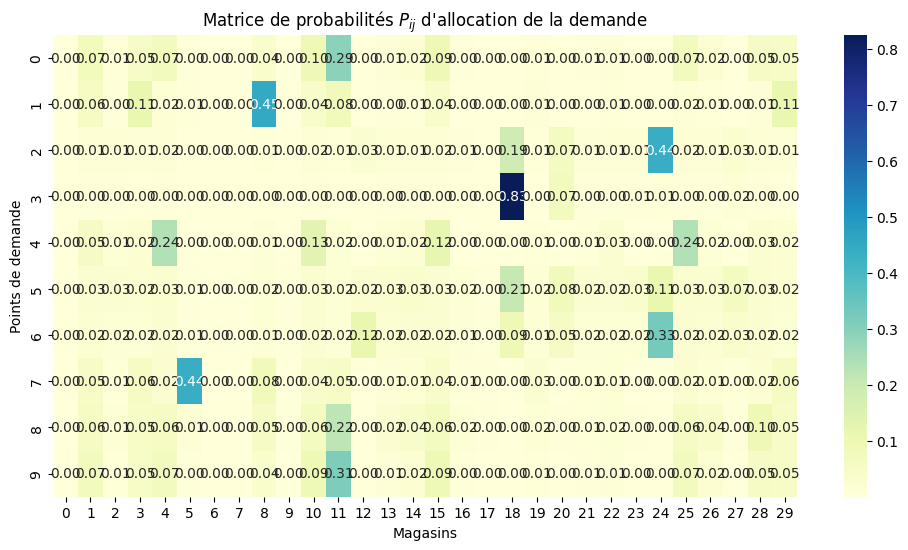

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(P_ij, annot=True, fmt=".2f", cmap="YlGnBu")
plt.xlabel("Magasins")
plt.ylabel("Points de demande")
plt.title("Matrice de probabilités $P_{ij}$ d'allocation de la demande")
plt.show()


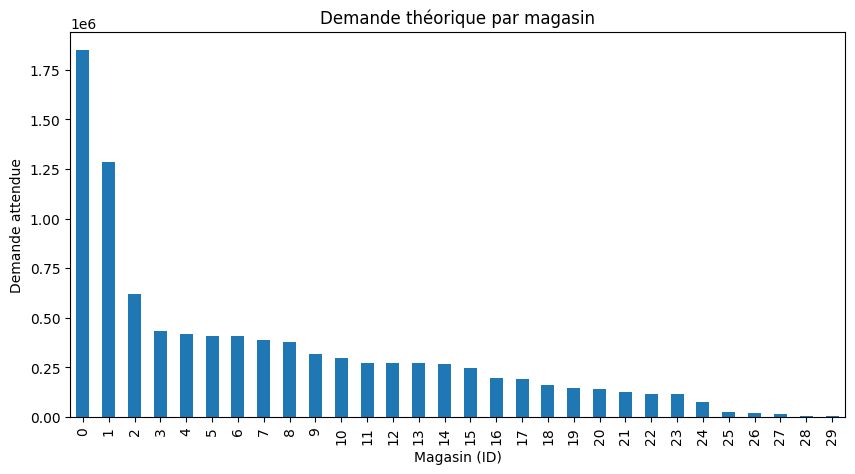

In [22]:
store_df['demande_attendue'] = demand_allocation.sum(axis=0)
store_df_sorted = store_df.sort_values('demande_attendue', ascending=False)

store_df_sorted.reset_index(drop=True, inplace=True)
store_df_sorted['magasin_id'] = range(len(store_df_sorted))

store_df_sorted.plot(x='magasin_id', y='demande_attendue', kind='bar', figsize=(10,5), legend=False)
plt.xlabel("Magasin (ID)")
plt.ylabel("Demande attendue")
plt.title("Demande théorique par magasin")
plt.show()


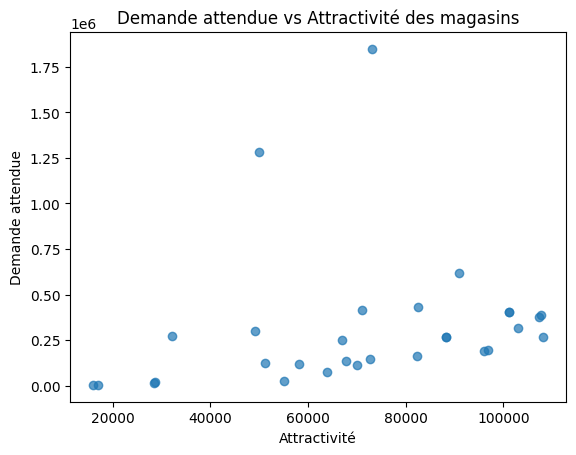

In [24]:
plt.scatter(store_results['attractiveness'], store_results['demande_attendue'], alpha=0.7)
plt.title("Demande attendue vs Attractivité des magasins")
plt.xlabel("Attractivité")
plt.ylabel("Demande attendue")
plt.show()


In [25]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 704.8 kB/s eta 0:00:00


In [26]:
store_df.columns

Index(['CENTER_LON_x', 'CENTER_LAT_x', 'TOTAL_POP_x', 'traffic_score',
       'num_competitors', 'num_antenna_3g4g', 'Villa', 'appartement',
       'non-residentiel', 'traditionnel', 'demande_attendue'],
      dtype='object')

In [29]:
import random
import numpy as np
import pandas as pd
from geopy.distance import geodesic
from deap import base, creator, tools, algorithms

# ==============================
# PARAMETERS
# ==============================
BUDGET = 500000
P_MAX = 3          # exactly 3 stores
D_MIN = 2.0        # km, min distance

NGEN = 50
POP_SIZE = 100
CX_PB = 0.7
MUT_PB = 0.2


# ==============================
# CONSTRAINT HELPERS
# ==============================
def distance(i, j):
    coord_i = (store_results.loc[i, "CENTER_LAT_x"], store_results.loc[i, "CENTER_LON_x"])
    coord_j = (store_results.loc[j, "CENTER_LAT_x"], store_results.loc[j, "CENTER_LON_x"])
    return geodesic(coord_i, coord_j).km


def check_constraints(individual):
    selected = [i for i, bit in enumerate(individual) if bit == 1]

    # Budget
    total_cost = np.dot(individual, store_results['cost'])
    if total_cost > BUDGET:
        return False

    # Min distance
    for i in range(len(selected)):
        for j in range(i+1, len(selected)):
            if distance(selected[i], selected[j]) < D_MIN:
                return False

    return True


# ==============================
# FITNESS FUNCTION
# ==============================
def evaluate(individual):
    if not check_constraints(individual):
        return (-1e6,)
    total_demand = np.dot(individual, store_results['expected_demand'])
    return (total_demand,)


# ==============================
# CUSTOM INITIALIZATION
# ==============================
def init_individual(icls, n_stores, p_max):
    """Create individual with exactly p_max stores = 1"""
    ind = [0] * n_stores
    chosen = random.sample(range(n_stores), p_max)
    for idx in chosen:
        ind[idx] = 1
    return icls(ind)


def mut_shuffle(individual):
    """Mutation: swap one selected store with an unselected one"""
    selected = [i for i, bit in enumerate(individual) if bit == 1]
    not_selected = [i for i, bit in enumerate(individual) if bit == 0]
    if selected and not_selected:
        out = random.choice(selected)
        inn = random.choice(not_selected)
        individual[out] = 0
        individual[inn] = 1
    return (individual,)


# ==============================
# GA SETUP
# ==============================
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("individual", init_individual, creator.Individual,
                 n_stores=len(store_results), p_max=P_MAX)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mut_shuffle)
toolbox.register("select", tools.selTournament, tournsize=3)


# ==============================
# RUN GA
# ==============================
def run_ga():
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.HallOfFame(1, similar=np.array_equal)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)

    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=CX_PB, mutpb=MUT_PB,
                                   ngen=NGEN, stats=stats, halloffame=hof,
                                   verbose=True)

    best_ind = hof[0]
    selected_stores = [i for i, bit in enumerate(best_ind) if bit == 1]

    print("\n=== BEST SOLUTION ===")
    print("Selected stores (indices):", selected_stores)
    print("Total cost:", np.dot(best_ind, store_results['cost']))
    print("Total expected demand:", np.dot(best_ind, store_results['expected_demand']))

    return selected_stores, best_ind


/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [30]:
if "cost" not in store_results.columns:
    np.random.seed(42)
    store_results['cost'] = np.random.randint(80000, 200000, size=len(store_results))

selected, sol = run_ga()

gen	nevals	avg    	max        
0  	100   	-673502	2.04362e+06
1  	76    	-210192	2.04362e+06
2  	80    	237607 	1.9009e+06 
3  	76    	512864 	1.96565e+06
4  	68    	965942 	1.96565e+06
5  	81    	963799 	1.96565e+06
6  	83    	1.0367e+06	1.96667e+06
7  	77    	1.18647e+06	2.16804e+06
8  	80    	1.17285e+06	1.96991e+06
9  	85    	1.10819e+06	2.23907e+06
10 	86    	1.05847e+06	2.47036e+06
11 	85    	1.16465e+06	2.47036e+06
12 	66    	1.17596e+06	2.47036e+06
13 	77    	1.52748e+06	2.47036e+06
14 	79    	1.35774e+06	2.73707e+06
15 	68    	1.4715e+06 	2.49004e+06
16 	79    	1.54021e+06	2.49004e+06
17 	69    	1.82848e+06	2.73707e+06
18 	75    	1.89385e+06	2.74165e+06
19 	80    	1.74789e+06	2.74165e+06
20 	79    	1.95599e+06	2.74165e+06
21 	80    	1.72031e+06	2.74165e+06
22 	71    	1.90225e+06	2.74165e+06
23 	79    	1.75947e+06	2.75096e+06
24 	75    	1.93935e+06	2.75096e+06
25 	83    	2.33572e+06	2.75096e+06
26 	81    	2.15937e+06	2.75096e+06
27 	67    	2.24453e+06	2.75096e+06
28 	81    	2.0

In [31]:
import matplotlib.pyplot as plt

def visualize_results(selected_stores, best_ind):
    # DataFrame des résultats
    store_results['selected'] = best_ind

    total_cost = np.dot(best_ind, store_results['cost'])
    total_demand = np.dot(best_ind, store_results['expected_demand'])

    print("\n--- OPTIMIZATION SUMMARY ---")
    print(f"Nombre de magasins ouverts : {len(selected_stores)}")
    print(f"Coût total (Dhs) : {total_cost:,.0f}")
    print(f"Demande totale captée (population) : {total_demand:,.0f}")

    # Scatter plot (visual spatial representation)
    plt.figure(figsize=(8,6))
    plt.scatter(store_results['CENTER_LON_x'], store_results['CENTER_LAT_x'],
                s=store_results['TOTAL_POP_x'] / 50,   # scale population size
                c="lightgray", alpha=0.6, label="Candidats")
    plt.scatter(store_results.loc[selected_stores, 'CENTER_LON_x'],
                store_results.loc[selected_stores, 'CENTER_LAT_x'],
                s=store_results.loc[selected_stores, 'TOTAL_POP_x'] / 50,
                c="red", edgecolor="black", label="Magasins sélectionnés")

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Sélection optimale de magasins (simulation)")
    plt.legend()
    plt.grid(True)
    plt.show()



--- OPTIMIZATION SUMMARY ---
Nombre de magasins ouverts : 4
Coût total (Dhs) : 493,422
Demande totale captée (population) : 2,750,964


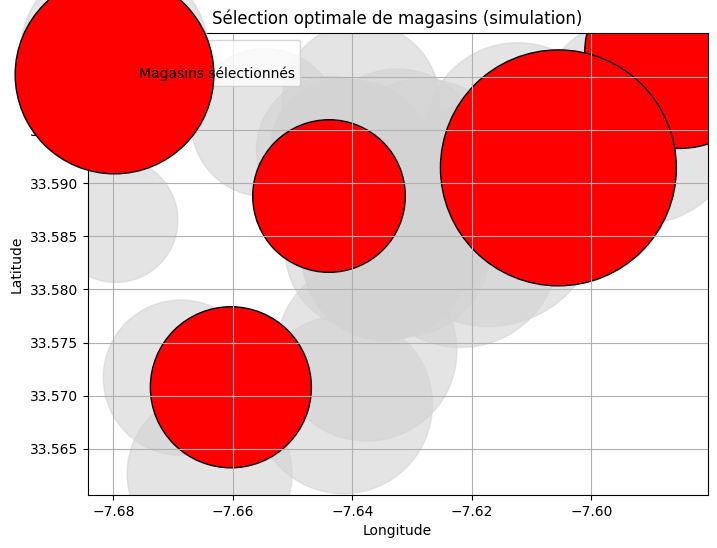

In [32]:
visualize_results(selected, sol)

In [33]:
import geopandas as gpd
from shapely.geometry import Point

def export_to_geojson(selected_stores, best_ind, filename="selected_stores.geojson"):
    # Add selection flag
    store_results['selected'] = best_ind

    # Build GeoDataFrame
    gdf = gpd.GeoDataFrame(
        store_results,
        geometry=[Point(xy) for xy in zip(store_results["CENTER_LON_x"],
                                          store_results["CENTER_LAT_x"])],
        crs="EPSG:4326"  # WGS84 (lat/lon)
    )

    # Export to GeoJSON (QGIS ready)
    gdf.to_file(filename, driver="GeoJSON")

    print(f"✅ GeoJSON exported: {filename}")


In [34]:
export_to_geojson(selected, sol, "ga_selected.geojson")

✅ GeoJSON exported: ga_selected.geojson
